In [1]:
#Importing Necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import array as arr
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [2]:
#Reading Train CSV
train=pd.read_csv('../input/robi-datathon-2-pre-assessment/train.csv')
train

,id,gender,s11,s12,s13,s16,s17,s18,s48,s52,...,n7,n8,n9,n10,n11,n12,n13,n14,n15,label
0,b'gAAAAABinOicS09vrmgh0_JyEHihI13ptO0rCyHP7l76...,M,Y,N,1,D,D,B,0,1,...,-9.126056,1.732291,3.698504,4.804517,1.544484,0,0,0.631220,5,0
1,b'gAAAAABinOiWGC1WhR6WYP0DA5ssGv9rIekrWUwCdJ8F...,M,Y,Y,1,D,D,B,1,1,...,-9.098287,1.505885,6.791357,6.110416,1.712354,0,0,0.392746,3,1
2,b'gAAAAABinOibTcOBFIVeA4nVF3FuFz_QX3ZlPPFc21gS...,M,Y,Y,1,D,D,B,0,1,...,-9.234894,1.503828,4.109685,3.953226,1.804260,0,0,0.222537,2,0
3,b'gAAAAABinOig-g3-Q1ggjlMhfUSdn21Aj5yVVeVvXbis...,F,Y,Y,1,D,D,B,0,1,...,-9.378025,1.485863,7.265876,4.559419,1.537645,0,0,0.154409,4,0
4,b'gAAAAABinOiXdoaNUzihOSbyY1tjWtd5EgMaXkkvH6SV...,M,N,Y,1,B,D,D,1,l,...,-9.261962,1.619210,3.737647,4.052003,1.637831,0,1,0.737560,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28317,b'gAAAAABinOiX2ss5U2ZT5zFd8zf7HcBDWPvbivNz5wAy...,M,Y,Y,1,D,D,B,0,1,...,-8.651173,1.877460,3.637551,11.404942,1.862441,0,0,0.019793,5,0
28318,b'gAAAAABinOiabmEADrCTZQktCKiahJkR_0kDa_8WOlos...,M,Y,Y,1,D,D,B,0,1,...,-8.833046,1.559138,4.247487,5.530054,1.671527,0,0,0.371074,2,0
28319,b'gAAAAABinOicscC37w1W9uiIlYL1U5D_mUtmgdUg8QTl...,F,Y,Y,1,D,D,B,0,1,...,-9.233722,1.455911,2.900249,6.058681,1.627479,0,1,0.826587,1,0
28320,b'gAAAAABinOib-JZ8iQDxjSRsa1dPT1TqeSQ_si4mAw5f...,M,Y,Y,1,B,C,B,1,1,...,-8.748941,2.074394,10.673259,11.387646,1.560391,0,0,0.103523,5,0


In [3]:
#Reading Test CSV
test=pd.read_csv('../input/robi-datathon-2-pre-assessment/test.csv')
test

,id,gender,s11,s12,s13,s16,s17,s18,s48,s52,...,n6,n7,n8,n9,n10,n11,n12,n13,n14,n15
0,b'gAAAAABinOi328DZcweGB4_nOyHA3Dy6o1YKYKyf3COx...,M,Y,Y,1,B,D,D,0,l,...,0.026301,-9.200175,2.122970,6.646617,4.801224,1.693087,0,0,0.439270,2
1,b'gAAAAABinOikutEIBjkUXl9lYTg4RI6jc4NfiMUCcVsn...,M,Y,Y,1,B,C,B,1,l,...,0.010774,-8.897092,1.770889,11.046294,6.407230,1.516728,0,0,0.084334,4
2,b'gAAAAABinOjBM70jBXOroAlUSq5lNXMd_oP0PU7jLQE5...,M,Y,N,1,B,D,B,1,l,...,0.016837,-9.173660,1.871872,2.805834,5.481219,1.788823,0,0,0.984210,0
3,b'gAAAAABinOimitAnqlgOcqnD_LeNL3WEbXNGvjd3QVPi...,M,Y,Y,1,D,D,B,0,1,...,0.015684,-9.178200,1.675028,6.354938,5.427266,1.792147,0,0,0.003492,1
4,b'gAAAAABinOi3W9p3Oka5MV_dc2TeorZUcIWOnnODSx7E...,M,Y,Y,1,D,C,B,1,1,...,0.006406,-8.726633,1.963535,6.810158,11.487845,1.880992,0,0,0.060614,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85060,b'gAAAAABinOjbnJVk2-nOVQsYB9p4DK26fTLLik_UR2H0...,M,Y,Y,1,C,C,C,1,l,...,0.011017,-8.994304,1.581816,9.265657,5.604845,1.746737,0,0,0.751100,0
85061,b'gAAAAABinOi7ixyXrlKYlx8D9i0-TIPD5elP2k-vuekn...,M,Y,Y,1,B,C,C,1,l,...,0.019550,-9.131275,1.526110,7.823166,5.458373,1.669676,0,0,0.903294,3
85062,b'gAAAAABinOi31zWSlD0OMhbBd3_weh7Kq6aPeO4yYqns...,M,N,Y,1,D,A,C,1,1,...,0.015461,-9.249529,1.505547,6.438985,3.429928,1.500925,0,0,0.571895,3
85063,b'gAAAAABinOjIe7jFVk9k7jiH8Y3rdpUHDTZG2T2isunp...,M,N,Y,1,B,D,D,1,l,...,0.010612,-9.229158,1.833286,5.383311,6.212552,1.730987,0,0,0.655693,6


In [4]:
test.head()

,id,gender,s11,s12,s13,s16,s17,s18,s48,s52,...,n6,n7,n8,n9,n10,n11,n12,n13,n14,n15
0,b'gAAAAABinOi328DZcweGB4_nOyHA3Dy6o1YKYKyf3COx...,M,Y,Y,1,B,D,D,0,l,...,0.026301,-9.200175,2.122970,6.646617,4.801224,1.693087,0,0,0.439270,2
1,b'gAAAAABinOikutEIBjkUXl9lYTg4RI6jc4NfiMUCcVsn...,M,Y,Y,1,B,C,B,1,l,...,0.010774,-8.897092,1.770889,11.046294,6.407230,1.516728,0,0,0.084334,4
2,b'gAAAAABinOjBM70jBXOroAlUSq5lNXMd_oP0PU7jLQE5...,M,Y,N,1,B,D,B,1,l,...,0.016837,-9.173660,1.871872,2.805834,5.481219,1.788823,0,0,0.984210,0
3,b'gAAAAABinOimitAnqlgOcqnD_LeNL3WEbXNGvjd3QVPi...,M,Y,Y,1,D,D,B,0,1,...,0.015684,-9.178200,1.675028,6.354938,5.427266,1.792147,0,0,0.003492,1
4,b'gAAAAABinOi3W9p3Oka5MV_dc2TeorZUcIWOnnODSx7E...,M,Y,Y,1,D,C,B,1,1,...,0.006406,-8.726633,1.963535,6.810158,11.487845,1.880992,0,0,0.060614,0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28322 entries, 0 to 28321
Data columns (total 36 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      28322 non-null  object 
 1   gender  28322 non-null  object 
 2   s11     28322 non-null  object 
 3   s12     28322 non-null  object 
 4   s13     28322 non-null  int64  
 5   s16     28322 non-null  object 
 6   s17     28322 non-null  object 
 7   s18     28322 non-null  object 
 8   s48     28322 non-null  int64  
 9   s52     28322 non-null  object 
 10  s53     28322 non-null  object 
 11  s54     2628 non-null   object 
 12  s55     3206 non-null   object 
 13  s56     0 non-null      float64
 14  s57     0 non-null      float64
 15  s58     28322 non-null  object 
 16  s59     0 non-null      float64
 17  s69     28322 non-null  object 
 18  s70     28322 non-null  object 
 19  s71     28322 non-null  object 
 20  n1      28322 non-null  float64
 21  n2      28322 non-null  float64
 22

In [6]:
test.shape

(85065, 35)

In [7]:
train.shape

(28322, 36)

In [8]:
#Dropping Empty Columns

train=train.drop(columns=['s56','s57','s59'], axis=1)

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28322 entries, 0 to 28321
Data columns (total 33 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      28322 non-null  object 
 1   gender  28322 non-null  object 
 2   s11     28322 non-null  object 
 3   s12     28322 non-null  object 
 4   s13     28322 non-null  int64  
 5   s16     28322 non-null  object 
 6   s17     28322 non-null  object 
 7   s18     28322 non-null  object 
 8   s48     28322 non-null  int64  
 9   s52     28322 non-null  object 
 10  s53     28322 non-null  object 
 11  s54     2628 non-null   object 
 12  s55     3206 non-null   object 
 13  s58     28322 non-null  object 
 14  s69     28322 non-null  object 
 15  s70     28322 non-null  object 
 16  s71     28322 non-null  object 
 17  n1      28322 non-null  float64
 18  n2      28322 non-null  float64
 19  n3      28322 non-null  int64  
 20  n4      28322 non-null  float64
 21  n5      28322 non-null  float64
 22

<AxesSubplot:xlabel='s13', ylabel='count'>

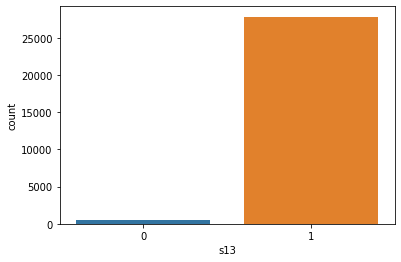

In [10]:
#Plotting Graph to Find Relevance

sns.countplot(train['s13'])

<AxesSubplot:xlabel='s48', ylabel='count'>

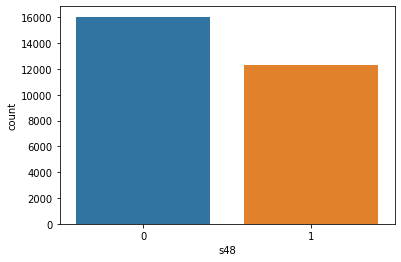

In [11]:
#Plotting Graph to Find Relevance

sns.countplot(train['s48'])

<AxesSubplot:xlabel='n12', ylabel='count'>

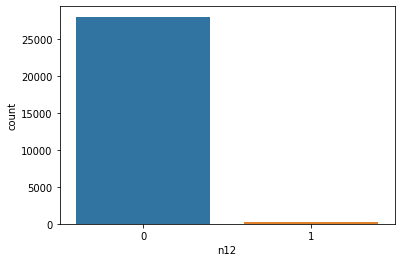

In [12]:
#Plotting Graph to Find Relevance

sns.countplot(train['n12'])

<AxesSubplot:xlabel='n13', ylabel='count'>

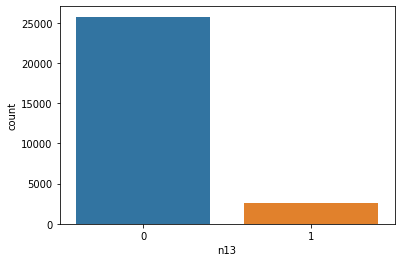

In [13]:
#Plotting Graph to Find Relevance

sns.countplot(train['n13'])

<AxesSubplot:xlabel='n15', ylabel='count'>

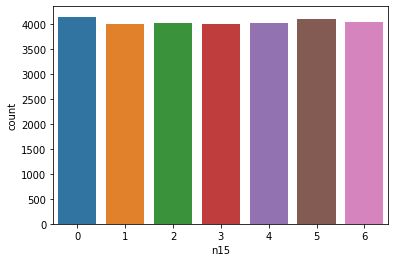

In [14]:
#Plotting Graph to Find Relevance

sns.countplot(train['n15'])

<AxesSubplot:xlabel='label', ylabel='count'>

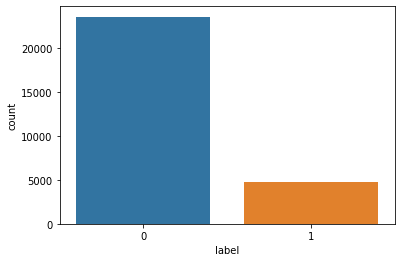

In [15]:
#Plotting Graph to Find Relevance

sns.countplot(train['label'])

In [16]:
#Plotting Graph to Find Relevance

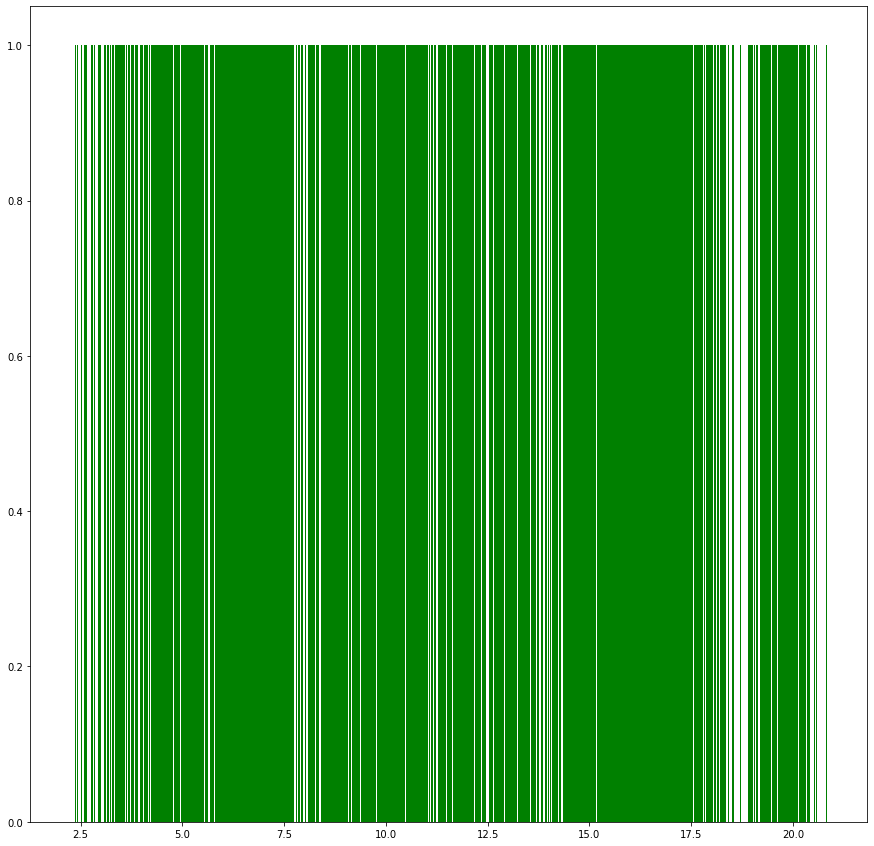

In [17]:
plt.figure(figsize =(15, 15))
plt.bar(train['n1'],train['label'], width = 0.01, color ='green')
plt.show()

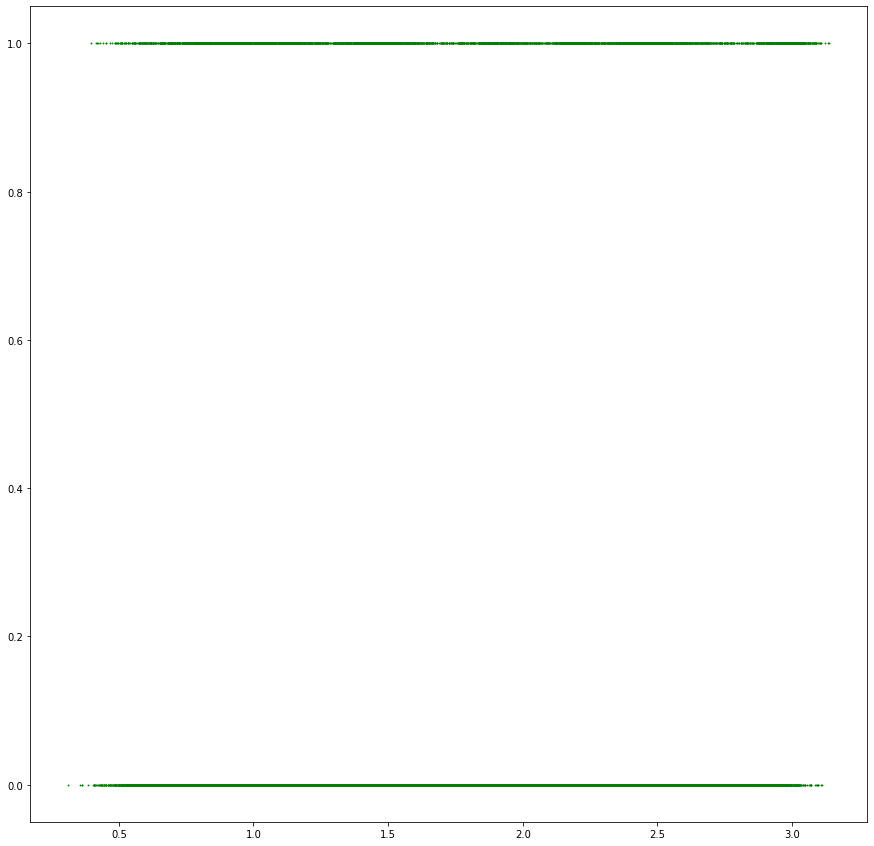

In [18]:
#Plotting Scatter Value to Find Relevance
plt.figure(figsize =(15, 15))
plt.scatter(train['n2'],train['label'], label= "stars", color= "green", marker= "*", s=1)

plt.show()

In [19]:
#Concat Train and Test File

train_len=len(train)
df=pd.concat([train,test], axis=0)
df=df.reset_index(drop=True)
df.head()

,id,gender,s11,s12,s13,s16,s17,s18,s48,s52,...,n10,n11,n12,n13,n14,n15,label,s56,s57,s59
0,b'gAAAAABinOicS09vrmgh0_JyEHihI13ptO0rCyHP7l76...,M,Y,N,1,D,D,B,0,1,...,4.804517,1.544484,0,0,0.631220,5,0.0,NaN,NaN,NaN
1,b'gAAAAABinOiWGC1WhR6WYP0DA5ssGv9rIekrWUwCdJ8F...,M,Y,Y,1,D,D,B,1,1,...,6.110416,1.712354,0,0,0.392746,3,1.0,NaN,NaN,NaN
2,b'gAAAAABinOibTcOBFIVeA4nVF3FuFz_QX3ZlPPFc21gS...,M,Y,Y,1,D,D,B,0,1,...,3.953226,1.804260,0,0,0.222537,2,0.0,NaN,NaN,NaN
3,b'gAAAAABinOig-g3-Q1ggjlMhfUSdn21Aj5yVVeVvXbis...,F,Y,Y,1,D,D,B,0,1,...,4.559419,1.537645,0,0,0.154409,4,0.0,NaN,NaN,NaN
4,b'gAAAAABinOiXdoaNUzihOSbyY1tjWtd5EgMaXkkvH6SV...,M,N,Y,1,B,D,D,1,l,...,4.052003,1.637831,0,1,0.737560,1,0.0,NaN,NaN,NaN


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113387 entries, 0 to 113386
Data columns (total 36 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      113387 non-null  object 
 1   gender  113387 non-null  object 
 2   s11     113387 non-null  object 
 3   s12     113387 non-null  object 
 4   s13     113387 non-null  int64  
 5   s16     113387 non-null  object 
 6   s17     113387 non-null  object 
 7   s18     113387 non-null  object 
 8   s48     113387 non-null  int64  
 9   s52     113387 non-null  object 
 10  s53     113387 non-null  object 
 11  s54     10371 non-null   object 
 12  s55     12627 non-null   object 
 13  s58     113387 non-null  object 
 14  s69     113387 non-null  object 
 15  s70     113387 non-null  object 
 16  s71     113387 non-null  object 
 17  n1      113387 non-null  float64
 18  n2      113387 non-null  float64
 19  n3      113387 non-null  int64  
 20  n4      113387 non-null  float64
 21  n5      11

In [21]:
#Dropping Empty Columns

df.reindex()
#df=df.drop(columns=['s56','s57','s59'],axis=1)

,id,gender,s11,s12,s13,s16,s17,s18,s48,s52,...,n10,n11,n12,n13,n14,n15,label,s56,s57,s59
0,b'gAAAAABinOicS09vrmgh0_JyEHihI13ptO0rCyHP7l76...,M,Y,N,1,D,D,B,0,1,...,4.804517,1.544484,0,0,0.631220,5,0.0,NaN,NaN,NaN
1,b'gAAAAABinOiWGC1WhR6WYP0DA5ssGv9rIekrWUwCdJ8F...,M,Y,Y,1,D,D,B,1,1,...,6.110416,1.712354,0,0,0.392746,3,1.0,NaN,NaN,NaN
2,b'gAAAAABinOibTcOBFIVeA4nVF3FuFz_QX3ZlPPFc21gS...,M,Y,Y,1,D,D,B,0,1,...,3.953226,1.804260,0,0,0.222537,2,0.0,NaN,NaN,NaN
3,b'gAAAAABinOig-g3-Q1ggjlMhfUSdn21Aj5yVVeVvXbis...,F,Y,Y,1,D,D,B,0,1,...,4.559419,1.537645,0,0,0.154409,4,0.0,NaN,NaN,NaN
4,b'gAAAAABinOiXdoaNUzihOSbyY1tjWtd5EgMaXkkvH6SV...,M,N,Y,1,B,D,D,1,l,...,4.052003,1.637831,0,1,0.737560,1,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113382,b'gAAAAABinOjbnJVk2-nOVQsYB9p4DK26fTLLik_UR2H0...,M,Y,Y,1,C,C,C,1,l,...,5.604845,1.746737,0,0,0.751100,0,NaN,NaN,NaN,NaN
113383,b'gAAAAABinOi7ixyXrlKYlx8D9i0-TIPD5elP2k-vuekn...,M,Y,Y,1,B,C,C,1,l,...,5.458373,1.669676,0,0,0.903294,3,NaN,NaN,NaN,NaN
113384,b'gAAAAABinOi31zWSlD0OMhbBd3_weh7Kq6aPeO4yYqns...,M,N,Y,1,D,A,C,1,1,...,3.429928,1.500925,0,0,0.571895,3,NaN,NaN,NaN,NaN
113385,b'gAAAAABinOjIe7jFVk9k7jiH8Y3rdpUHDTZG2T2isunp...,M,N,Y,1,B,D,D,1,l,...,6.212552,1.730987,0,0,0.655693,6,NaN,NaN,NaN,NaN


In [22]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113387 entries, 0 to 113386
Data columns (total 36 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      113387 non-null  object 
 1   gender  113387 non-null  object 
 2   s11     113387 non-null  object 
 3   s12     113387 non-null  object 
 4   s13     113387 non-null  int64  
 5   s16     113387 non-null  object 
 6   s17     113387 non-null  object 
 7   s18     113387 non-null  object 
 8   s48     113387 non-null  int64  
 9   s52     113387 non-null  object 
 10  s53     113387 non-null  object 
 11  s54     10371 non-null   object 
 12  s55     12627 non-null   object 
 13  s58     113387 non-null  object 
 14  s69     113387 non-null  object 
 15  s70     113387 non-null  object 
 16  s71     113387 non-null  object 
 17  n1      113387 non-null  float64
 18  n2      113387 non-null  float64
 19  n3      113387 non-null  int64  
 20  n4      113387 non-null  float64
 21  n5      11

<AxesSubplot:>

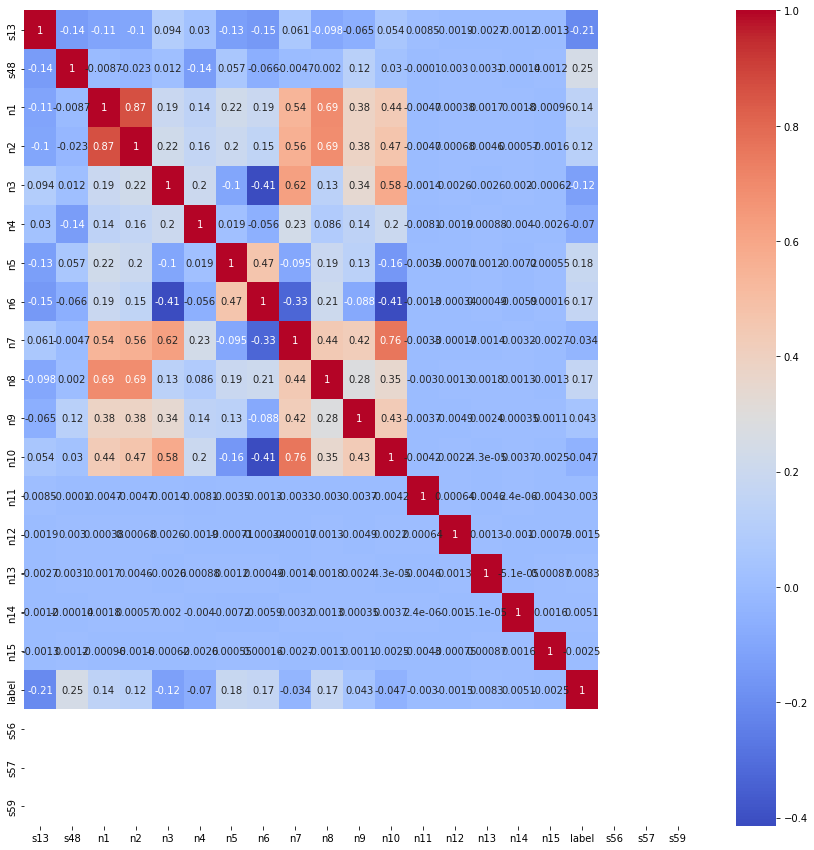

In [23]:
#Showing Heatmap

corr=df.corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [24]:
#Preprocessing Data 

from sklearn.preprocessing import LabelEncoder
cols=['gender','s11','s12','s16','s17','s18','s52','s53','s54','s55','s58','s69','s70','s71','s56','s57','s59']
le=LabelEncoder()
for col in cols:
    df[col]=le.fit_transform(df[col])
    df.head()

In [25]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113387 entries, 0 to 113386
Data columns (total 36 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      113387 non-null  object 
 1   gender  113387 non-null  int64  
 2   s11     113387 non-null  int64  
 3   s12     113387 non-null  int64  
 4   s13     113387 non-null  int64  
 5   s16     113387 non-null  int64  
 6   s17     113387 non-null  int64  
 7   s18     113387 non-null  int64  
 8   s48     113387 non-null  int64  
 9   s52     113387 non-null  int64  
 10  s53     113387 non-null  int64  
 11  s54     113387 non-null  int64  
 12  s55     113387 non-null  int64  
 13  s58     113387 non-null  int64  
 14  s69     113387 non-null  int64  
 15  s70     113387 non-null  int64  
 16  s71     113387 non-null  int64  
 17  n1      113387 non-null  float64
 18  n2      113387 non-null  float64
 19  n3      113387 non-null  int64  
 20  n4      113387 non-null  float64
 21  n5      11

In [26]:
df.head()

,id,gender,s11,s12,s13,s16,s17,s18,s48,s52,...,n10,n11,n12,n13,n14,n15,label,s56,s57,s59
0,b'gAAAAABinOicS09vrmgh0_JyEHihI13ptO0rCyHP7l76...,1,1,0,1,3,3,1,0,1,...,4.804517,1.544484,0,0,0.631220,5,0.0,0,0,0
1,b'gAAAAABinOiWGC1WhR6WYP0DA5ssGv9rIekrWUwCdJ8F...,1,1,1,1,3,3,1,1,1,...,6.110416,1.712354,0,0,0.392746,3,1.0,0,0,0
2,b'gAAAAABinOibTcOBFIVeA4nVF3FuFz_QX3ZlPPFc21gS...,1,1,1,1,3,3,1,0,1,...,3.953226,1.804260,0,0,0.222537,2,0.0,0,0,0
3,b'gAAAAABinOig-g3-Q1ggjlMhfUSdn21Aj5yVVeVvXbis...,0,1,1,1,3,3,1,0,1,...,4.559419,1.537645,0,0,0.154409,4,0.0,0,0,0
4,b'gAAAAABinOiXdoaNUzihOSbyY1tjWtd5EgMaXkkvH6SV...,1,0,1,1,1,3,3,1,2,...,4.052003,1.637831,0,1,0.737560,1,0.0,0,0,0


In [27]:
#Splitting Data

train1=df.iloc[:train_len,:]
test1=df.iloc[train_len:,:]

In [28]:
train1.tail()

,id,gender,s11,s12,s13,s16,s17,s18,s48,s52,...,n10,n11,n12,n13,n14,n15,label,s56,s57,s59
28317,b'gAAAAABinOiX2ss5U2ZT5zFd8zf7HcBDWPvbivNz5wAy...,1,1,1,1,3,3,1,0,1,...,11.404942,1.862441,0,0,0.019793,5,0.0,0,0,0
28318,b'gAAAAABinOiabmEADrCTZQktCKiahJkR_0kDa_8WOlos...,1,1,1,1,3,3,1,0,1,...,5.530054,1.671527,0,0,0.371074,2,0.0,0,0,0
28319,b'gAAAAABinOicscC37w1W9uiIlYL1U5D_mUtmgdUg8QTl...,0,1,1,1,3,3,1,0,1,...,6.058681,1.627479,0,1,0.826587,1,0.0,0,0,0
28320,b'gAAAAABinOib-JZ8iQDxjSRsa1dPT1TqeSQ_si4mAw5f...,1,1,1,1,1,2,1,1,1,...,11.387646,1.560391,0,0,0.103523,5,0.0,0,0,0
28321,b'gAAAAABinOiZ3mCQAtoJFXj-Ymjhi9FbbZ_Ypi5gDoAE...,1,1,1,1,3,3,1,1,2,...,4.584967,1.777995,0,1,0.435079,5,0.0,0,0,0


In [29]:
test1.tail()

,id,gender,s11,s12,s13,s16,s17,s18,s48,s52,...,n10,n11,n12,n13,n14,n15,label,s56,s57,s59
113382,b'gAAAAABinOjbnJVk2-nOVQsYB9p4DK26fTLLik_UR2H0...,1,1,1,1,2,2,2,1,2,...,5.604845,1.746737,0,0,0.751100,0,NaN,0,0,0
113383,b'gAAAAABinOi7ixyXrlKYlx8D9i0-TIPD5elP2k-vuekn...,1,1,1,1,1,2,2,1,2,...,5.458373,1.669676,0,0,0.903294,3,NaN,0,0,0
113384,b'gAAAAABinOi31zWSlD0OMhbBd3_weh7Kq6aPeO4yYqns...,1,0,1,1,3,0,2,1,1,...,3.429928,1.500925,0,0,0.571895,3,NaN,0,0,0
113385,b'gAAAAABinOjIe7jFVk9k7jiH8Y3rdpUHDTZG2T2isunp...,1,0,1,1,1,3,3,1,2,...,6.212552,1.730987,0,0,0.655693,6,NaN,0,0,0
113386,b'gAAAAABinOiiLo4KNZVgClHgtOFRzEU9O97My6MowJFa...,1,1,1,1,3,3,1,0,1,...,4.890686,1.844714,0,0,0.785251,2,NaN,0,0,0


In [30]:
X=train1.drop(columns=['id','label'],axis=1)
y=train1['label']

In [31]:
X.shape

(28322, 34)

In [32]:
from sklearn.model_selection import train_test_split, cross_val_score
def classify(model,x,y):
    x_train, x_test, y_train, y_test =train_test_split(X,y,test_size=0.25,random_state=42)
    model.fit(x_train, y_train)
    print('Accuracy:', model.score(x_test,y_test))
    score=cross_val_score(model,X,y,cv=5)
    print(score)
    print('CV Score:',np.mean(score))

In [33]:
#Predicting Using Sklearn

from lightgbm import LGBMClassifier
model=LGBMClassifier()
classify(model,X,y)

Accuracy: 0.8844795932777856
[0.87096205 0.88402471 0.87888418 0.88400424 0.87358757]
CV Score: 0.8782925499025136


In [34]:
#Predicting Using Sklearn

from sklearn.neural_network import MLPClassifier
model= MLPClassifier()
classify(model,X,y)

Accuracy: 0.8810902414913148
[0.86760812 0.88084731 0.87464689 0.88329802 0.87235169]
CV Score: 0.8757504076473139


In [35]:
#Predicting Using Sklearn

from sklearn.ensemble import GradientBoostingClassifier
model= GradientBoostingClassifier()
classify(model,X,y)

Accuracy: 0.8853269312244033
[0.87431598 0.88296558 0.88012006 0.88435734 0.87535311]
CV Score: 0.879422412374527


In [36]:
#Using Best Prediction for Result

model=LGBMClassifier()
model.fit(X,y)

LGBMClassifier()

In [37]:
X_test=test1.drop(columns=['id','label'], axis=1)
X_test.head()

,gender,s11,s12,s13,s16,s17,s18,s48,s52,s53,...,n9,n10,n11,n12,n13,n14,n15,s56,s57,s59
28322,1,1,1,1,1,3,3,0,2,1,...,6.646617,4.801224,1.693087,0,0,0.439270,2,0,0,0
28323,1,1,1,1,1,2,1,1,2,1,...,11.046294,6.407230,1.516728,0,0,0.084334,4,0,0,0
28324,1,1,0,1,1,3,1,1,2,1,...,2.805834,5.481219,1.788823,0,0,0.984210,0,0,0,0
28325,1,1,1,1,3,3,1,0,1,1,...,6.354938,5.427266,1.792147,0,0,0.003492,1,0,0,0
28326,1,1,1,1,3,2,1,1,1,1,...,6.810158,11.487845,1.880992,0,0,0.060614,0,0,0,0


In [38]:
pred=model.predict(X_test)
pred

array([1., 1., 1., ..., 0., 1., 0.])

In [39]:
pred.shape

(85065,)

In [40]:
#Converting Datatype to Integer

float_array = np.array(pred)
print(float_array)

print('After converting numpy float array to int array')
int_array = float_array.astype(int)
print(int_array)

[1. 1. 1. ... 0. 1. 0.]
After converting numpy float array to int array
[1 1 1 ... 0 1 0]


In [41]:
#Submission File
'''test_preds /= 10
print("Saving submission file")
submission = pd.DataFrame.from_dict({
    'id': test_id,
    'label': test_preds
})
submission.to_csv("submission.csv", index=False)'''

sub=pd.DataFrame({'id':test['id'],'label':int_array})
sub.to_csv('final.csv', index=False)